**Read README.md first.**

author: Xu Chen, 2021.11， xuchen21@mails.ucas.ac.cn

In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import numpy.fft as fft
import sys
sys.path.append('/data/inspur_disk01/userdir/xuc/FAST/test_fast/hifast_dev/hifast/ripple/')
# sys.path.append('/data/inspur_disk01/userdir/xuc/FAST/test_fast/test_pipe/')
from util import *
from copy import deepcopy
from tqdm import tqdm

In [2]:
subname = '/data/inspur_disk01/userdir/xuc/FAST/G15/new_21/drift7/sub/G15_7_arcdrift-M12_W-20210809-specs_T-bld.hdf5'
sub = h5py.File(subname,'r')

# example polar yy

以偏振yy为例，其实找RFI这里是合并偏振做的，即`polar = 'average'`, 并截取了100MHz宽度

In [3]:
frange = [1300,1460]
data = get_data(sub,polar='yy',xrange = frange)
freq = sub['freq'][:]
# fuse = (freq > frange[0]) & (freq < frange[1])
# freq = freq[fuse]
is_on = sub['is_on'][:]

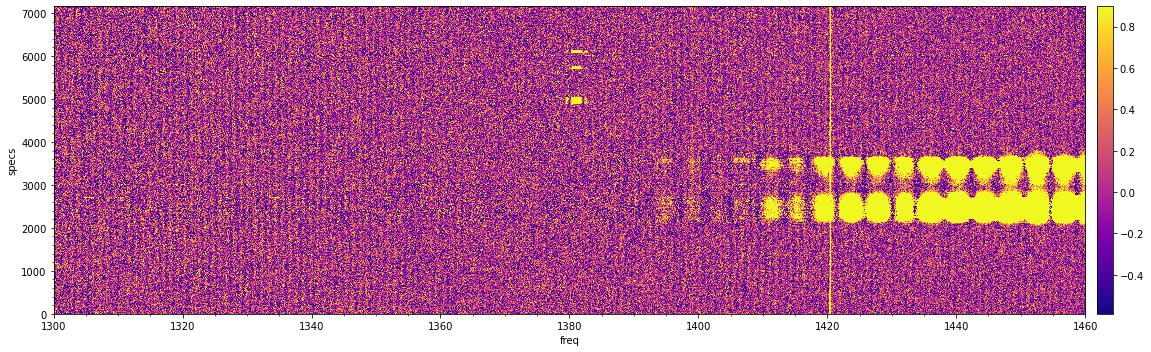

In [4]:
plot_waterfall(sub,data,per_vmin_max=.90,figsize=(18,5),cmap = 'plasma',xrange = frange)

# time RFI


* --time_rfi：标记时域上突然出现的RFI，根据占据的频率长度，分为short-freq/long-freq。
    对该频率区间内的所有谱线做频率方向的平均后，画出一维的图。如果有`--lf`或`--sf`，可以省略`--time_rfi`

* --sf
* --sf_frange: 一个典型的1～2MHz宽时域RFI，经常出现在1380～1382MHz。
* --sf_file: 或者可以指定一个二维数组的npy文件路径，在里面循环找，例如以下是只找时域RFI:

* --sf_frange_step:如果sf_frange和sf_file不指定，将以这个step(MHz)在频率上循环，对每个区间找一次时域RFI
    
* --sf_times: 大于各谱线之中，中值的10倍，初步认为异常
* --sf_thr: 边缘处与附近值的差是中值的倍数，找出时间方向的边缘处陡峭的
* --sf_rfi_last: 持续出现的谱线数
* --sf_T_thr_times: 选定区域后，大于温度阈值的被标记. 如果为0相当于频段内全扔掉
* --sf_ext: 选定区域后，扩展边缘

* --lf
* --lf_beams: 已知出现大卫星干扰的波束，其他不搜寻。如果不设置就对所有波束搜寻。
* --lf_frange: 大范围频率
* --lf_times: 大于各谱线之中，中值1.5倍，初步认为异常.
* --lf_thr: 不需要边缘陡峭，所以设为0
* --lf_rfi_last: 持续出现的谱线数
* --lf_ext: 选定区域后，扩展边缘

输出文件名含tr

寻找时域RFI之前，先计算一下谱线的RMS。这里选取了比较平坦的1390～1400mhz，选择一个合适的平滑sigma。

In [34]:
import mpl_interactions.ipyplot as iplt

In [35]:
%matplotlib ipympl
spec = deepcopy(data[0,:])
def test_gauss(freq,sigma):
    from hifast.utils.misc import smooth1d
    sm = smooth1d(spec,method='gaussian',sigma=sigma)
    return sm

fig,ax = plt.subplots(figsize=(10,2))
iplt.plot(freq,spec,label = 'ori')
controls = iplt.plot(freq, test_gauss,  sigma=np.arange(2, 20, 1),xlim = [1380,1430],
                     ylim=[-1,1.2],color = 'C1',label='smooth')
iplt.title("sigma is {sigma:.2f}", controls=controls['sigma'])
plt.legend()
plt.show()

Canvas(toolbar=Toolbar(toolitems=[('Home', 'Reset original view', 'home', 'home'), ('Back', 'Back to previous …

VBox()

In [4]:
from markRFI import mask_time_rfi

对于一个短横条样子的时域RFI，使用前面的sf参数控制。

| --sf para | function para | 建议 |
|---|---|---|
| --sf_frange | frange | 一般是1380mhz附近有这种rfi，但不全是。推荐设置--sf_frange_step 20或40等进行循环 |
| --sf_times | times | 根据下图虚线决定阈值是中值的多少倍，这里我使用的3倍 |
| --sf_thr | thr | 有时这种rfi边界平缓，一般比较陡峭，可以试验看看 |
| --sf_rfi_last | rfi_width_lim | 根据rfi时域宽度判断，对于下面右边的rfi wide<=30 |
| --sf_T_thr_times | T_thr_times | mask的范围，根据下面瀑布图的效果增减, 或直接设为0 |
| --sf_ext | ext_add | 一般不用扩展，设为0 |

In [8]:
%matplotlib inline

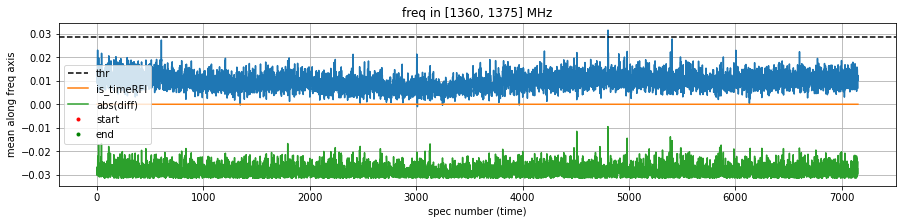

No short-freq time rfi is found.
Finish


In [5]:
s_rfi = mask_time_rfi(data,freq,T_thr_times = 2.5, rtype = 'short-freq',frange =[1360,1375],times = 3,thr = 1,
                      ext_add=0,rfi_width_lim = 10,plot = True,rms_frange=[1390,1400])

rfis start at tn = [4885 5683 6062], end in tn = [5029 5756 6134]


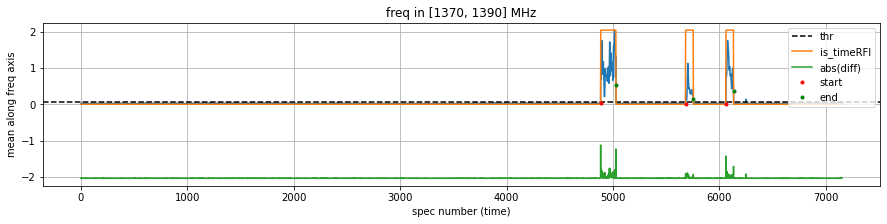

INFO: Looking for short-freq time RFI in [1370, 1390] ... [markRFI]
mask frange: [1375.35476685 1387.98904419]
mask frange: [1376.76239014 1385.99395752]
mask frange: [1377.15530396 1386.76834106]
Found :D
Finish


In [5]:
s_rfi = mask_time_rfi(data,freq,T_thr_times = -1e4, rtype = 'short-freq',frange =[1370,1390],times = 3,thr = 1,
                      ext_add=0,rfi_width_lim = 10,plot = True,rms_frange=[1390,1400])

这个很强的RFI形状类似sinc函数，于是扔掉这一频段

(1360.0, 1400.0)

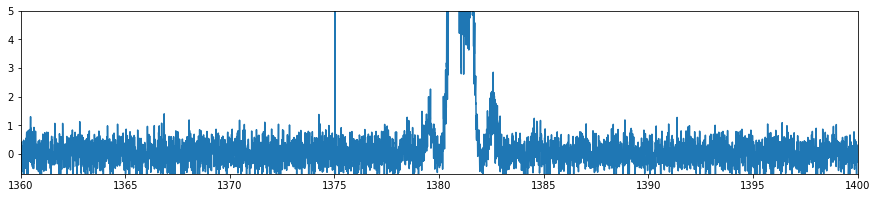

In [11]:
tn = 4950
plt.figure(figsize=(15,3))
plt.plot(freq,data[tn])
# plt.hlines(y=[-2.5*RMS,2.5*RMS],xmin=1360,xmax=1400,color='k')
plt.ylim(-.7,5)
plt.xlim(1360,1400)

In [7]:
T = deepcopy(data)
T[s_rfi] = np.nan

确认RFI是否基本mask掉

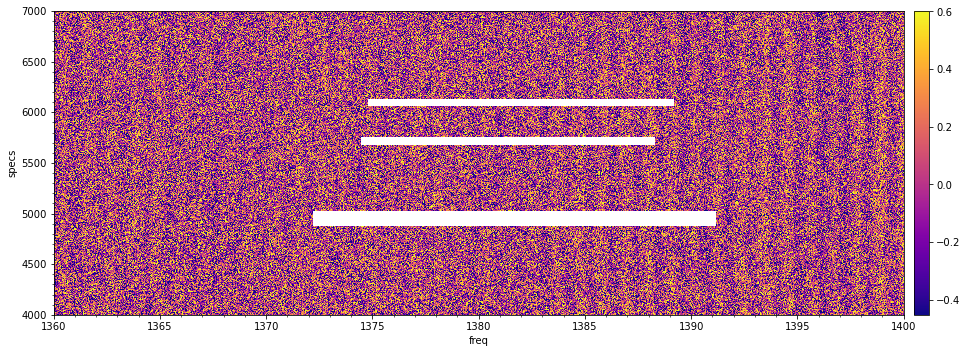

In [8]:
plot_waterfall(sub,T,per_vmin_max=.80,figsize=(15,5),cmap = 'plasma',xylim = (1360,1400,4000,7000),xrange = frange)

通过类似的lf参数，也可以找出很强的长频率时域RFI

| --lf para | function para | 建议 |
|---|---|---| 
| --lf_frange | frange | [1400,1460]或者避开银河系[1421,1460]，RFI集中的频率 |
| --lf_times | times | 根据图片确定阈值倍数|
| --lf_thr | thr | 由于是平缓的边界，直接设为0|
| --lf_rfi_last | rfi_width_lim | 一般宽度300～500以上，如果刚好在边缘有些难搞，可能只有50以上|
| --lf_ext | ext_add | 适当扩展，但是会多扔谱线，建议0～2|
| --lf_sepfile | - | 如果输入的是'input_subname'，None则从sub文件找lf；否则从sep文件找。
| | |自动搜索的路径顺序是上一级是/sep/、sub文件所在路径或者指定的路径|

INFO: Looking for long-freq time RFI ... [markRFI]
rfis start at tn = [2077], end in tn = [3725]
After extension, rfis start at tn = [1614], end in tn = [4186]


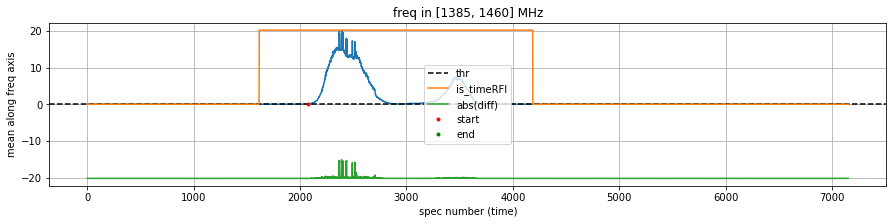

Mask the whole spec with rfi :(
Found :D
Finish


In [6]:
l_rfi = mask_time_rfi(data,freq, rtype = 'long-freq',frange =[1385,1460],times = 2,thr = 0,
                      ext_add=50,rfi_width_lim = 50,plot = True)

检查mask区域边缘的谱线平均后是否还有大RFI。因为xx偏振的RFI很弱，一起对比。

In [24]:
data_p = get_data(sub,polar='merged',xrange = frange)

(-0.2, 0.5)

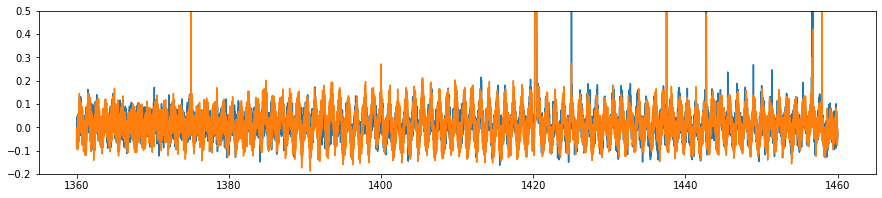

In [25]:
tn = 4186#1614
plt.figure(figsize=(15,3))
#plt.plot(freq,np.mean(data_p[tn-100:tn,:],axis = 0))
plt.plot(freq,np.mean(data_p[tn:tn+100,:],axis = 0))
plt.ylim(-.2,.5)

In [7]:
is_rfi = s_rfi|l_rfi

由于有大时域RFI很难处理，可以考虑全部扔掉有问题的谱线，补充观测。实际上可以对影响不太大的<1380mhz单独处理。这里示例就先都扔掉了

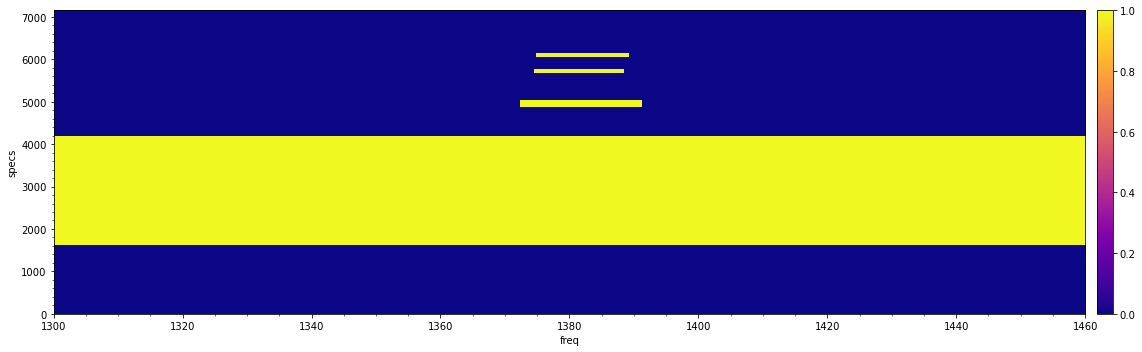

In [11]:
plot_waterfall(sub,is_rfi,per_vmin_max=.90,figsize=(18,5),cmap = 'plasma',xrange = frange)

In [12]:
# rfiname = '/data/inspur_disk01/userdir/xuc/FAST/G15/new_21/drift7/rfi/G15_7_arcdrift-M12_W-20210809-specs_T-bld-tr.hdf5'
# rfi = h5py.File(rfiname,'r')
# is_rfi = rfi['is_rfi'][:]

# MW range
有MW的区域，下面会被替代为驻波

(1420.0, 1420.7)

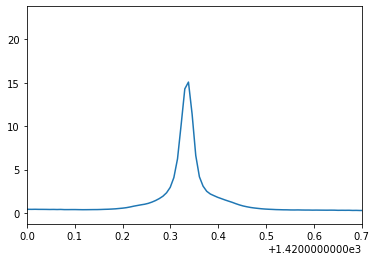

In [13]:
plt.plot(freq,np.mean(data,axis = 0))
plt.xlim(1420.0,1420.7)

In [8]:
mw_frange = (1420.2,1420.5)
from sw_fft_example import *
mw_use = (freq > mw_frange[0])&(freq < mw_frange[1])

接下来，考虑离散fourier变换的两端会拟合效果很差，可以切去两端或者在两端延长，使得最终的结果保持良好的去驻波效果。这里不再演示

# Replace RFI or strong sources

* --rfi_method: 防止大rfi/强源干扰fft，简化版只提供'near ripple'方法

* --rms_sigma: 如果区间有干扰，还是用该频率减去一个高斯平滑，得到准确的rms。此为高斯滤波的sigma。
* -rfi, --rfi_fname: 指定标记rfi的文件。无则自动到输入文件的上一级名为/rfi/的文件夹里找含-tr的文件，找不到则在当前路径找。

* --mw_frange: 银河系(或者M31，M33都)存在的区域

这里'near ripple'使用高流量处附近的驻波替代源或RFI。例如
```
fname = subnames[1]
outdir = './data'
sepname='/data/M31_snapshot/data/M31_SnapShot_6_snapshot-M'
python /data/inspur_disk01/userdir/ucas_students/xuc/FAST/G15/test_pipe/cli_baseline_fft.py $fname \
        --outdir $outdir -sep $sepname  \
        --mw_frange 1420.3 1423.3 --rms_sigma 6 --rms_frange 1390 1400 \
        --rfi_method 'near ripple' --times_lower_thr 4 \
        --rfi_width_lim 15 --ext_sec 20 --ext_freq 1.3 \
        --fft_method rfft --chan_wide 5 --chan_narr 3 \
        --amp_thr_mean_factor 1.05 --amp_thr_factor 1.4 --choose_method 'all' \
        --rip_base --rip_1mhz --rip_0_04mhz --fft_ylim -5 160 \
        --plot --ylim -1 .5 --vmin_max -.05 .05 -f --fill_rfi nan --keep_polar || exit 1 
```

* 只需要已知时域rfi的文件，即*-tr*。    
  如果没有时域RFI，设置-rfi 'none'即可。
* --times_lower_thr:大于RMS这么多倍的会被替代
* --rfi_width_lim: 要替换的rfi/源，频率上的宽度应该大于一阈值(通道数)
* --ext_sec: (接上面的)并向两边扩展通道数
* --ext_freq: 先扩展边缘(MHz)，再寻找强流量两边的最低点，先使用左/右边的一段更干净一点的代替强流量处

* 输出文件名含fft_blde.

通过单条谱线尝试参数，划分被replace的范围.之前已经确定了rms_sigma=6,rms_frange=[1390,1400]，这里测试,times_lower_thr=4,rfi_width_lim=10, ext_sec=2，使得不要替代过多的噪声而速度变慢。（这里主要replace了MW、RFI）

In [10]:
%matplotlib ipympl
def test_replace(freq,rms_sigma=6,rms_frange=[1390,1400],times_lower_thr=4,rfi_width_lim=15, ext_sec=20,ext_freq=1.3):

    fdelta = freq[1]-freq[0] 
    N = len(freq)
    ext = int(np.around(ext_freq / fdelta))
    
    from markRFI import real_rms,rms
    RMS = real_rms(spec,freq,sigma=rms_sigma,rms_vrange=rms_frange)
    thr_lower = RMS*times_lower_thr
    low_use = (spec > thr_lower) | is_rfi[tn]
    
    from markRFI import get_startend
    start,end = get_startend(low_use,rfi_width_lim, ext_sec)
    from sw_fft_example import replace_spec
    spec_ = deepcopy(spec)
    newspec = deepcopy(spec)
    newspec_ = deepcopy(spec)
    MAX = np.max(spec)
    if np.sum(mw_use)>0:
        spec[mw_use] = MAX * 20
    
    newspec,usespec,rep_area = replace_spec(tn,spec_,freq,low_use,rfi_width_lim, ext_sec, 
                                   ext, RMS, MAX,test=True)

    strange = np.where(np.abs(newspec) > times_lower_thr * RMS)[0]
    newspec[strange] = np.random.normal(scale=RMS, size=len(strange))

    return rep_area,usespec,newspec

def test_replace_rep(freq,rms_sigma=6,rms_frange=[1390,1400],times_lower_thr=4,rfi_width_lim=15, ext_sec=20,ext_freq=1.3):
    rep_area,usespec,newspec = test_replace(freq,rms_sigma,rms_frange,times_lower_thr,rfi_width_lim, ext_sec,ext_freq)
    return rep_area
def test_replace_use(freq,rms_sigma=6,rms_frange=[1390,1400],times_lower_thr=4,rfi_width_lim=15, ext_sec=20,ext_freq=1.3):
    rep_area,usespec,newspec = test_replace(freq,rms_sigma,rms_frange,times_lower_thr,rfi_width_lim, ext_sec,ext_freq)
    return usespec
def test_replace_new(freq,rms_sigma=6,rms_frange=[1390,1400],times_lower_thr=4,rfi_width_lim=15, ext_sec=20,ext_freq=1.3):
    rep_area,usespec,newspec = test_replace(freq,rms_sigma,rms_frange,times_lower_thr,rfi_width_lim, ext_sec,ext_freq)
    return newspec-2#.5

def test_replace_thr(freq,rms_sigma=6,rms_frange=[1390,1400],times_lower_thr=4,rfi_width_lim=15, ext_sec=20,ext_freq=1.3):
    from markRFI import real_rms,rms
    RMS = real_rms(spec,freq,sigma=rms_sigma,rms_vrange=rms_frange)

    thr_lower = RMS*times_lower_thr
    thr = np.full(len(freq),thr_lower)
    return thr

如果mw_use是有True的，这个区域就会被替换，下面是例子

In [11]:
tn = 4900
xlim = [1360,1430]
ylim = [-3,2]

#spec = deepcopy(np.mean(data[tn-5:tn+5,:],axis = 0))
spec = deepcopy(data[tn])
fig = plt.figure(figsize=(30,3))
ax = fig.add_subplot(111)
iplt.plot(freq,spec,label='original',alpha = .5)
# plt.plot(freq,is_rfi[tn]*1.1,'k',alpha=.5,label='is_rfi')
from hifast.utils.misc import smooth1d
sm = smooth1d(spec,method='gaussian',sigma=6)
ax.plot(freq,sm,'m',alpha=.5,label='smooth')
#iplt.plot(freq,mw_use*1.5,label='mw',alpha = .5)
controls = iplt.plot(freq, test_replace_rep,times_lower_thr=np.arange(1,12,.5),
                     rfi_width_lim=np.arange(5,50,1).astype(int), 
                     ext_sec=np.arange(1,20,1).astype(int),
                     ext_freq=np.arange(1.3,5,0.1),xlim=xlim,ylim=ylim,label='rep area')
iplt.plot(freq,test_replace_use,controls = controls,
                     alpha=.5,xlim=xlim,ylim=ylim,label = 'copy from')
iplt.plot(freq,test_replace_new,controls = controls,
                     alpha=.5,xlim=xlim,ylim=ylim,label = 'after replace')
iplt.plot(freq,test_replace_thr,'k--',controls = controls,
                     alpha=.5,xlim=xlim,ylim=ylim,label = 'thr')
ax.grid();ax.legend(loc='right')
plt.show()

Canvas(toolbar=Toolbar(toolitems=[('Home', 'Reset original view', 'home', 'home'), ('Back', 'Back to previous …

VBox()

这样我们就将有强源的地方替换了。如果mw_use不设置，只有高于阈值的mw会被替换，需要注意，有的谱线h会因为银河系太窄不符合要被替换的宽度要求，这时还是查看单条谱线，降低限制；如果同时还有比较宽的时域rfi，不如直接给固定MW范围

## replace
前面确定好了参数，处理所有谱线

In [9]:
%matplotlib inline
rep_args = {}
rep_args['rms_sigma'] = 6
rep_args['rms_frange'] = [1390,1400]
rep_args['times_lower_thr'] = 4.5
rep_args['rfi_width_lim'] = 10
rep_args['ext_sec'] = 2
rep_args['ext_freq'] = 1.3

In [10]:
data_rep = replace_rfi(data,freq,time_rfi =is_rfi, method='near_ripple',mw_frange= mw_frange, **rep_args)

INFO: Replace RFI with near_ripple method ... [sw_fft_example]


100%|██████████| 7154/7154 [00:11<00:00, 602.35it/s] 


瀑布图的效果

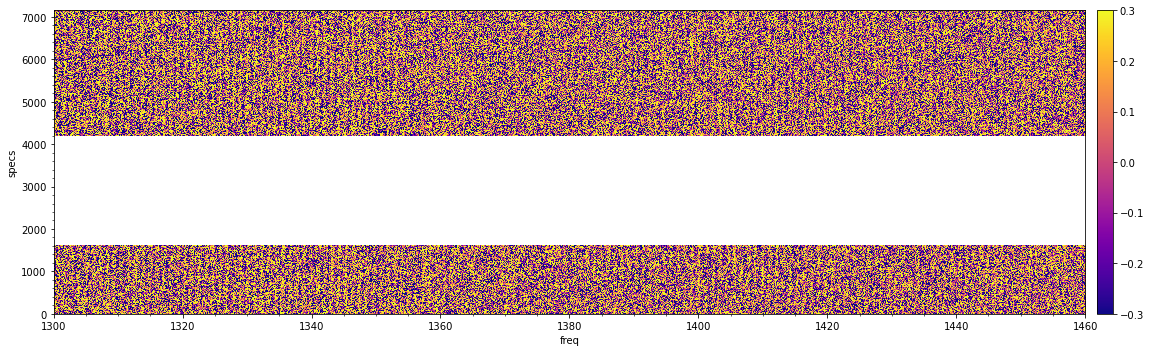

In [11]:
#plot_waterfall(sub,data = data,vmin_max=[-.3,.3],cmap='plasma',figsize=(18,5),xrange = frange)
plot_waterfall(sub,data = data_rep,vmin_max=[-.3,.3],cmap='plasma',figsize=(18,5),xrange = frange)

# FFT remove 1MHz ripples

* --fft_method: 目前只提供rfft。mean和median的方法见‘cli_baseline_mean去基线‘

* --amp_thr_mean_factor: fourier空间的平均振幅大于阈值的模，会被识别为已知的几种驻波。这里输入的是中值的倍数
* --amp_thr_factor: fourier空间的每一谱线的振幅大于阈值，会被选中为驻波一部分被去除。这里输入的是中值的倍数
* --comp_wide: 距离驻波的模的中心左右各(2 * chan - 1)个通道数的模在Fourier空间的宽度，作为驻波的一部分被选中，这里为由于fourier空间中峰比较宽，多选一些
  --comp_narr: 同理，窄一些的
* --choose_method: 选择fourier模的方法，'all'或者'interpolate'
  
* --rip_base: 去除基频(实空间的常数)
* --rip_1mhz: fft去除1.08mhz 驻波，单镜都有的
* --rip_2mhz: fft去除1.92mhz 驻波，只有M06 yy有
* --rip_0_04mhz: fft去除0.039mhz 驻波，很弱的偏振驻波，由于光纤反射

* --fft_ylim: 画fft模的上下限 

* --fill_rfi: 对输入的rfi区域，可以填nan或者保持原样。对应'nan','rfi'。需要注意只有输入对应RFI文件才能填nan。

然后对data_rep_进行FFT

In [12]:
sw = SW_FFT(data_rep, freq, 10)
sw.do_fft()

/data/inspur_disk01/userdir/xuc/FAST/test_fast/hifast_dev/hifast/ripple/sw_fft_example.py:308: RuntimeWarning: divide by zero encountered in true_divide
  self.period = 1/self.x


In [13]:
x = sw.x
amp_data = sw.amp
amp_mean = np.nanmean(amp_data,axis=0)
amp_off = np.nanmean(amp_data[~is_on],axis=0)

Text(0.5, 24.0, 't [$\\mu s$]')

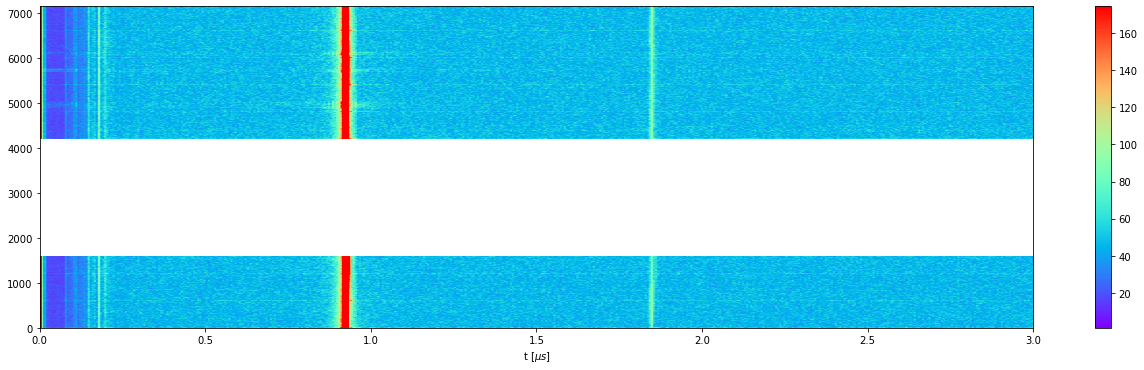

In [14]:
plt.figure(figsize=(18,5))
vmin,vmax = percent_vminmax(amp_data,percent = .999)
plt.imshow(amp_data,origin='lower',aspect='auto',extent=(x[0],x[-1],0,amp_data.shape[0]),
        vmin=vmin,vmax=vmax,cmap='rainbow')

plt.tight_layout()
plt.colorbar()
plt.xlim(0,3)
plt.xlabel("t [$\mu s$]")

这里先给出Fourier空间中取模的成分范围，单位是$\mu s$，分宽和窄两种

In [17]:
comp_wide=0.09
comp_narr=0.03
from sw_fft import comp2chan
chan_wide, cw = comp2chan(freq,comp_wide)
chan_narr, cn = comp2chan(freq,comp_narr)
print(f"chan_wide = {cw}, chan_narrow = {cn}")
is_excluded_mean = np.all(is_rfi, axis=1)

chan_wide = 13, chan_narrow = 3


内置的驻波种类，在[$\mu s$]轴上的大概范围，和选取的最大通道数一半

In [18]:
sw_periods=['1mhz', '2mhz', '0_04mhz']
sw_conf = get_sw_conf(chan_wide, chan_narr)
sw_conf

{'1mhz': {'xlims': [[0.9, 0.95], [1.8, 1.9]], 'nchans': [7, 2]},
 '2mhz': {'xlims': [[0.5, 0.6]], 'nchans': [7]},
 '0_04mhz': {'xlims': [[25, 26]], 'nchans': [2]}}

通过平均所有振幅，决定该波束存在哪些驻波

In [19]:
def test_amp_mean(x,amp_thr_mean_factor):
    sw.gen_amp_thr_s(amp_thr_mean_factor,amp_thr_solo_factor=1.4,is_on=is_on,is_excluded_mean=is_excluded_mean)
    loc = []
    for key in sw_periods:
        sw.find_sw_loc(xlims=sw_conf[key]['xlims'])
        if np.sum(sw.bingo_list) > 0:
            loc += [sw.loc_list,]
    loc = np.hstack((loc))
    select = np.full(x.shape,np.nan)
    select[loc] = 40
    print("---------------------------------")
    return select

def test_amp_mean_line(x,amp_thr_mean_factor):
    amp_thr = sw.amp_thr_mean
    return np.full(len(x),amp_thr)

改变这里的amp_thr_mean_factor，选择的驻波数量会变化(print的变化在log窗口里)

In [20]:
%matplotlib ipympl
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(211) 
ax.set_xlim(-.01,2)
iplt.plot(x,amp_mean, label = 'amp mean')
controls = iplt.plot(x,test_amp_mean,'^',amp_thr_mean_factor=np.arange(1,2,0.025),
                     xlim=[-.01,2],ylim=[0,150],label='selected')
iplt.plot(x,test_amp_mean_line,'k--',controls=controls,
                     alpha=.5,xlim=[-.01,2],ylim=[0,150],label = 'thr')
ax.grid();ax.legend(loc = 2)
ax.set_xlabel('t [$\mu$s]')
ax.set_ylabel('amp')

ax = fig.add_subplot(212) 
iplt.plot(x,amp_mean, label = 'amp mean')
iplt.plot(x,test_amp_mean,'^',controls=controls,
                     xlim=[25,26],ylim=[0,150],label='selected')
iplt.plot(x,test_amp_mean_line,'k--',controls=controls,
                      alpha=.5,xlim=[25,26],ylim=[0,150],label = 'thr')
ax.set_xlim(25,26)
ax.grid();ax.legend(loc = 2)
ax.set_xlabel('t [$\mu$s]')
ax.set_ylabel('amp')
plt.tight_layout()

Canvas(toolbar=Toolbar(toolitems=[('Home', 'Reset original view', 'home', 'home'), ('Back', 'Back to previous …

VBox()

find ripple 1.08841 MHz,0.91877 mu s,locate in 147
find ripple 0.54236 MHz,1.84380 mu s,locate in 295
find ripple 1.73909 MHz,0.57501 mu s,locate in 92
find ripple 0.03920 MHz,25.51313 mu s,locate in 4082
---------------------------------


VBox()

find ripple 1.08841 MHz,0.91877 mu s,locate in 147
find ripple 0.54236 MHz,1.84380 mu s,locate in 295
find ripple 1.73909 MHz,0.57501 mu s,locate in 92
find ripple 0.03920 MHz,25.51313 mu s,locate in 4082
---------------------------------
find ripple 1.08841 MHz,0.91877 mu s,locate in 147
find ripple 0.54236 MHz,1.84380 mu s,locate in 295
---------------------------------
find ripple 1.08841 MHz,0.91877 mu s,locate in 147
find ripple 0.54236 MHz,1.84380 mu s,locate in 295
---------------------------------
find ripple 1.08841 MHz,0.91877 mu s,locate in 147
find ripple 0.54236 MHz,1.84380 mu s,locate in 295
---------------------------------
find ripple 1.08841 MHz,0.91877 mu s,locate in 147
find ripple 0.54236 MHz,1.84380 mu s,locate in 295
---------------------------------


从平均的fourier模，可以看出明显的几种驻波，1mhz和它的倍频、0.92mhz周期RFI的前几个成分

同理，决定单条谱线适用的阈值倍数amp_thr_factor和取模通道数，chan_wide,chan_narr。这里可视化测试off的谱线举例

In [21]:
tn = 0
def test_amp_solo(x,amp_thr_mean_factor,amp_thr_solo_factor,comp_wide,comp_narr):
    from sw_fft import comp2chan
    chan_wide, cw = comp2chan(freq,comp_wide)
    chan_narr, cn = comp2chan(freq,comp_narr)
    print(f"comp_wide = {comp_wide}, comp_narrow = {comp_narr}")
    print(f"chan_wide = {cw}, chan_narrow = {cn}")
    sw_conf1 = get_sw_conf(chan_wide, chan_narr)
    sw.gen_amp_thr_s(amp_thr_mean_factor,amp_thr_solo_factor,is_on=is_on,is_excluded_mean=is_excluded_mean)
    
    sw.is_use_sw_chan = np.full(x.shape,False)
    for key in sw_periods:
        sw.find_sw_loc(xlims=sw_conf1[key]['xlims'])
        sw.find_sw_chans(nchans=sw_conf1[key]['nchans'])
        is_use_sw_chan_amp = sw.is_use_sw_chan & (amp_data[tn] > sw.amp_thr_solo[tn])
    
    select = np.full(x.shape,0)   
    select[is_use_sw_chan_amp] = amp_data[tn][is_use_sw_chan_amp] 
    print("---------------------------------")
    return select


def test_amp_solo_line(x,amp_thr_mean_factor,amp_thr_solo_factor,comp_wide,comp_narr):
    amp_thr = sw.amp_thr_solo[~is_on][tn][0]
    return np.full(len(x),amp_thr)

dx = x[1] - x[0]

In [22]:
%matplotlib ipympl
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(211) 
xlim=[-.01,2];ylim=[0,150]
iplt.plot(x,amp_data[tn], label = f'amp tn = {tn}')
controls = iplt.plot(x,test_amp_solo,amp_thr_mean_factor=1.1,amp_thr_solo_factor=np.arange(1,3,0.02),
                     comp_wide=np.arange(dx,0.2,dx),comp_narr=np.arange(dx,0.1,dx),
                     xlim=xlim,ylim=ylim,label='selected')
iplt.plot(x,test_amp_solo_line,'k--',controls=controls,
                     alpha=.5,xlim=xlim,ylim=ylim,label = 'thr')
ax.grid();ax.legend(loc = 2)
ax.set_xlabel('t [$\mu$s]')
ax.set_ylabel('amp')

xlim=[25,26];ylim=[0,150]
ax = fig.add_subplot(212) 
iplt.plot(x,amp_data[tn], label = f'amp tn = {tn}')
iplt.plot(x,test_amp_solo,controls=controls,
                     xlim=xlim,ylim=ylim,label='selected')
iplt.plot(x,test_amp_solo_line,'k--',controls=controls,
                      alpha=.5,xlim=xlim,ylim=ylim,label = 'thr')
ax.grid();ax.legend(loc = 2)
ax.set_xlabel('t [$\mu$s]')
ax.set_ylabel('amp')
plt.tight_layout()

Canvas(toolbar=Toolbar(toolitems=[('Home', 'Reset original view', 'home', 'home'), ('Back', 'Back to previous …

VBox()

comp_wide = 0.006250154975919127, comp_narrow = 0.006250154975919127
chan_wide = 0, chan_narrow = 0
find ripple 1.08841 MHz,0.91877 mu s,locate in 147
find ripple 0.54236 MHz,1.84380 mu s,locate in 295
---------------------------------
46.4285107638498


VBox()

comp_wide = 0.006250154975919127, comp_narrow = 0.006250154975919127
chan_wide = 0, chan_narrow = 0
find ripple 1.08841 MHz,0.91877 mu s,locate in 147
find ripple 0.54236 MHz,1.84380 mu s,locate in 295
---------------------------------
46.4285107638498
comp_wide = 0.006250154975919127, comp_narrow = 0.006250154975919127
chan_wide = 0, chan_narrow = 0
find ripple 1.08841 MHz,0.91877 mu s,locate in 147
find ripple 0.54236 MHz,1.84380 mu s,locate in 295
---------------------------------
79.85703851382169
comp_wide = 0.006250154975919127, comp_narrow = 0.006250154975919127
chan_wide = 0, chan_narrow = 0
find ripple 1.08841 MHz,0.91877 mu s,locate in 147
find ripple 0.54236 MHz,1.84380 mu s,locate in 295
---------------------------------
79.85703851382169
comp_wide = 0.08750216966286778, comp_narrow = 0.006250154975919127
chan_wide = 13, chan_narrow = 0
find ripple 1.08841 MHz,0.91877 mu s,locate in 147
find ripple 0.54236 MHz,1.84380 mu s,locate in 295
---------------------------------
79.

下图为1mhz驻波邻近几个模的的相位,noise on的相位有所漂移

Text(0, 0.5, 'phi[rad]')

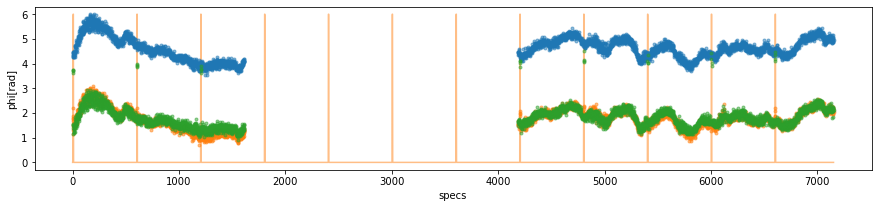

In [15]:
%matplotlib inline
phi = deepcopy(sw.phi)
phi[phi<0] = phi[phi<0] +2 * np.pi
plt.figure(figsize=(15,3))
plt.plot(is_on*6,c='C1',alpha=.5)
plt.plot(np.arange(data_rep.shape[0]),phi[:,146],'.',alpha=.5) 
plt.plot(np.arange(data_rep.shape[0]),phi[:,147],'.',alpha=.5) 
plt.plot(np.arange(data_rep.shape[0]),phi[:,148],'.',alpha=.5) 
plt.xlabel("specs")
plt.ylabel("phi[rad]")

振幅，有几个区间是RFI影响了

Text(0, 0.5, 'amp')

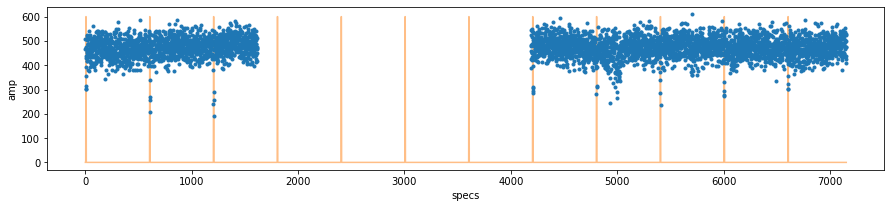

In [16]:
%matplotlib inline
amp1 = amp_data[:,147]
plt.figure(figsize=(15,3))
plt.plot(is_on*600,c='C1',alpha=.5)
plt.plot(np.arange(data_rep.shape[0]),amp1,'.')
plt.xlabel("specs")
plt.ylabel("amp")

对于测试数据，我选择了以下参数.`choose_method`有选择所有模'all'和线性插值'interpolate'两种方式，可以分别尝试效果。

现在使用完整的函数进行测试

In [17]:
fft_args = {}
fft_args['amp_thr_mean_factor'] = 1.1
fft_args['amp_thr_solo_factor'] = 1.4
fft_args['comp_wide'] = 0.09 
fft_args['comp_narr'] = 0.03
fft_args['choose_method'] = 'all'
fft_args['sw_periods'] = ['1mhz', '2mhz', '0_04mhz']
fft_args['sw_base'] = True
fft_args['is_on'] = is_on
fft_args['is_excluded_mean'] = np.all(is_rfi, axis=1)

In [18]:
sw_data = fit_sw_fft(data_rep, freq, nproc=10,  **fft_args)

all_chan_wide = 13, all_chan_narrow = 3


/data/inspur_disk01/userdir/xuc/FAST/test_fast/hifast_dev/hifast/ripple/sw_fft_example.py:308: RuntimeWarning: divide by zero encountered in true_divide
  self.period = 1/self.x


find ripple 1.09586 MHz,0.91252 mu s,locate in 146
find ripple 0.54236 MHz,1.84380 mu s,locate in 295


remove standing waves之后的

In [19]:
rmsw_data = data - sw_data

下面可以画一下单条谱线的效果，有的区间std有所降低

In [20]:
from hifast.utils.misc import smooth1d
from markRFI import std,real_std

0.3585981736283147 0.34937001313337174 0.3578109546217031 1.0264137165413223 1.0241604636088473


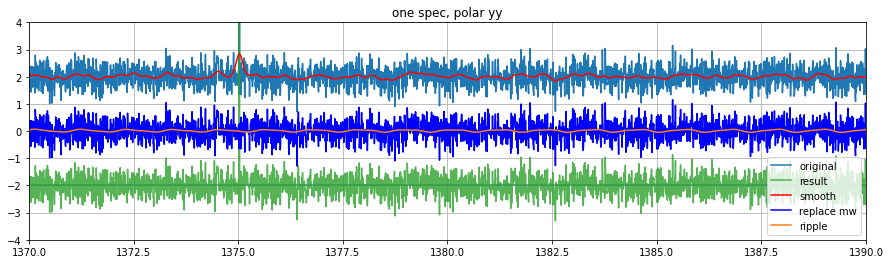

In [21]:
%matplotlib inline
tn = 200
fig = plt.figure(figsize=(15,4))
ax = fig.add_subplot(111)
ax.hlines([0,-2],freq[0],freq[-1],alpha = .8)
ax.plot(freq,data[tn]+2,label='original')
ax.plot(freq,rmsw_data[tn] -2,label='result',c='C2',alpha = .8)
ax.plot(freq,smooth1d(data[tn],method='gaussian', sigma=10) +2,'r',label = 'smooth')
ax.plot(freq,data_rep[tn],'b',label='replace mw')
ax.plot(freq,sw_data[tn],c= 'C1',label='ripple')
#ax.set_xlim(freq[0],freq[-1])
ax.set_xlim(1370,1390)
ax.set_ylim(-4,4) 
ax.grid();ax.legend();ax.set_title(f'one spec, polar yy')

spec = data[tn]
std_range = [1380,1390]
ori = std(spec,freq,std_range)
real = real_std(spec,freq,10,std_range)
ret = std(rmsw_data[tn],freq,std_range)
print(ori,real,ret,ori/real,ret/real)

平均10条谱线效果更明显，std降低了很多

0.11961110243130006 0.1122001681129079 0.032976992210376976 1.066051009040686 0.29391214616712497


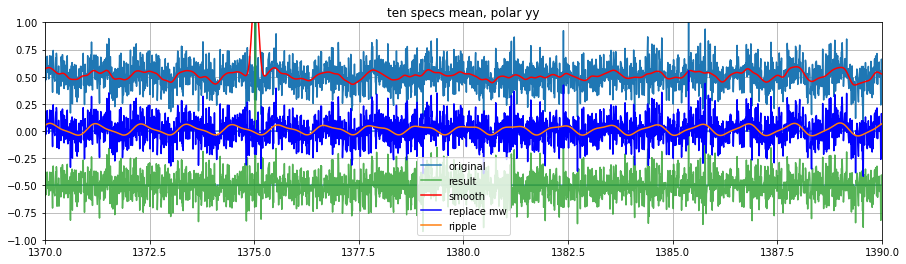

In [22]:
%matplotlib inline
fig = plt.figure(figsize=(15,4))
ax = fig.add_subplot(111)
ax.hlines([0,-.5],freq[0],freq[-1],alpha = .8)
ax.plot(freq,np.mean(data[tn-5:tn+5],axis=0)+.5,label='original')
ax.plot(freq,np.mean(rmsw_data[tn-5:tn+5],axis=0) -.5,label='result',c='C2',alpha = .8)
ax.plot(freq,np.mean(smooth1d(data[tn-5:tn+5],method='gaussian', sigma=10),axis=0) +.5,'r',label = 'smooth')
ax.plot(freq,np.mean(data_rep[tn-5:tn+5],axis=0),'b',label='replace mw')
ax.plot(freq,np.mean(sw_data[tn-5:tn+5],axis=0),c= 'C1',label='ripple')
#ax.set_xlim(freq[0],freq[-1])
ax.set_xlim(1370,1390)
ax.set_ylim(-1,1) 
ax.grid();ax.legend();ax.set_title(f'ten specs mean, polar yy')

spec = np.mean(data[tn-5:tn+5],axis=0)
std_range = [1380,1390]
ori = std(spec,freq,std_range)
real = real_std(spec,freq,10,std_range)
ret = std(np.mean(sw_data[tn-5:tn+5],axis=0),freq,std_range)
print(ori,real,ret,ori/real,ret/real)

瀑布图效果

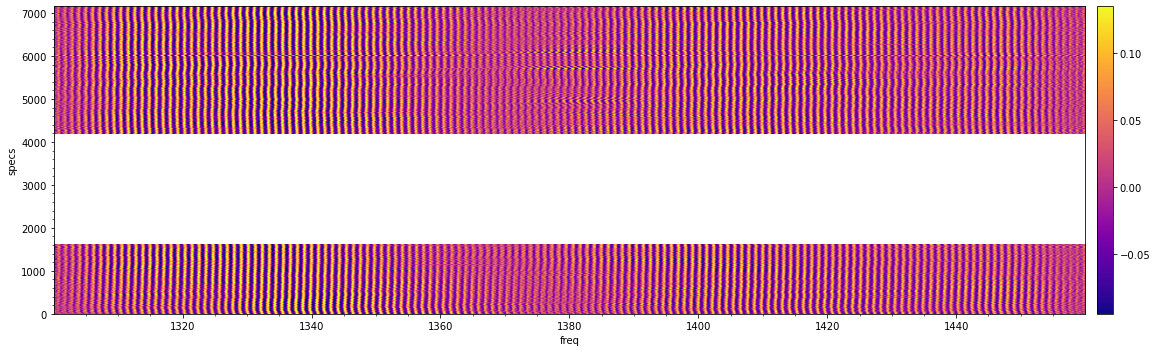

In [23]:
plot_waterfall(sub,data = sw_data,per_vmin_max=.98,cmap='plasma',figsize=(18,5))

In [25]:
rmsw_data[is_rfi] = np.nan

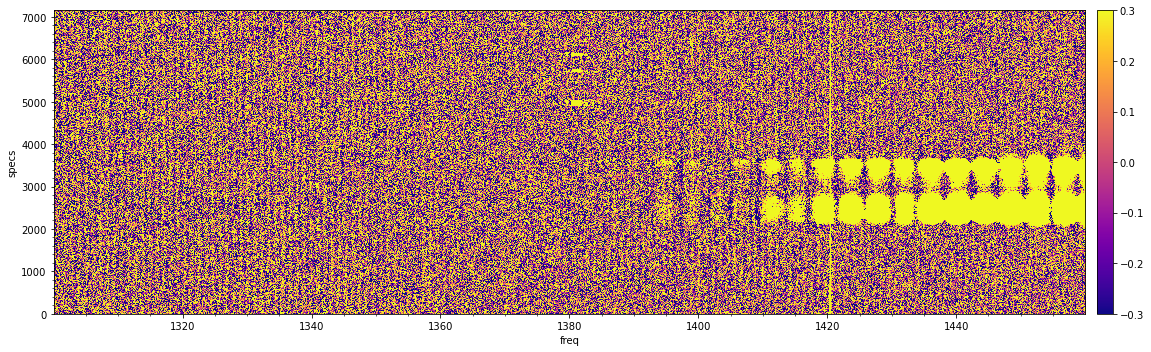

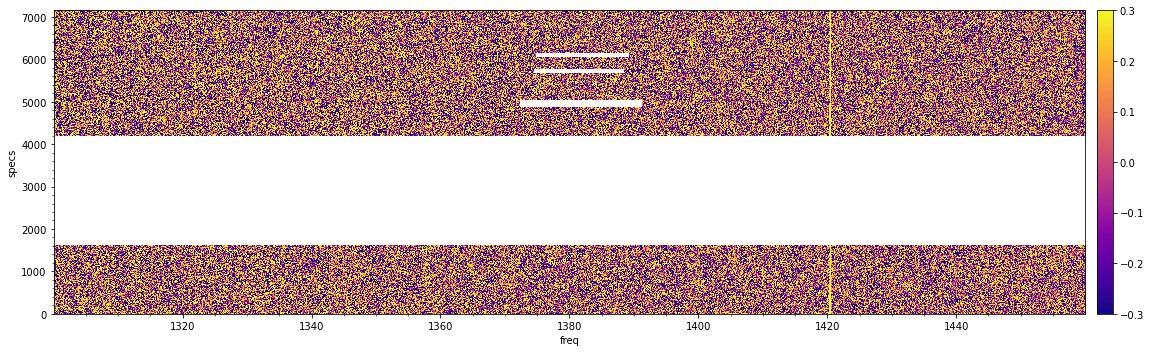

In [26]:
plot_waterfall(sub,data = data,vmin_max=[-.3,.3],cmap='plasma',figsize=(18,5))
plot_waterfall(sub,data = rmsw_data,vmin_max=[-.3,.3],cmap='plasma',figsize=(18,5))

# 平均值/中值谱线去基线(cli_baseline_mean)

* --sub_method: mean或median，取平均或中值前后若干条谱线作为基线
* --nspec: 平均谱线条数，默认200条。过少容易损失信号，过多容易驻波变化了。

输出文件名含mean_bld/med_bld


In [97]:
sep = h5py.File('/data/inspur_disk01/userdir/jyj/FAST/jingyj/G15_new/G15_7/data/G15_7_arcdrift-M12_W-20210809-specs_T.hdf5','r')
data_sep = get_data(sep,polar='yy')[:600]
is_on = sep['is_on'][:600]

In [98]:
sw_mean = fit_ripple(data_sep, method='mean',is_on=is_on,nspec=200)

INFO: Fit baseline ripple with mean method ... [sw_fft_example]
mean 200
use all specs to mean


100%|██████████| 4/4 [00:00<00:00, 2075.10it/s]

mean 200



100%|██████████| 596/596 [02:02<00:00,  4.87it/s]


In [99]:
rmsw_data_mean = data_sep - sw_mean

平均方法的

Text(0.5, 1.0, 'ten specs mean, polar yy')

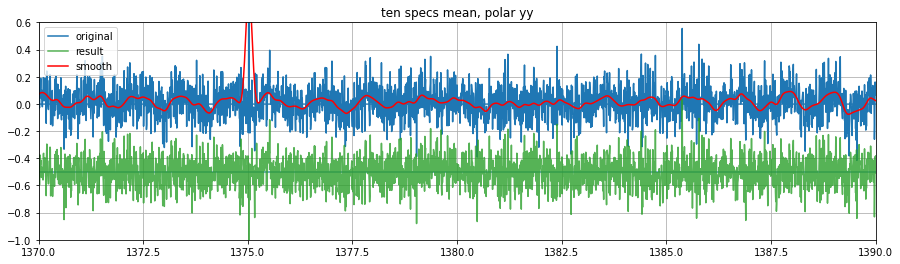

In [100]:
fig = plt.figure(figsize=(15,4))
ax = fig.add_subplot(111)
ax.hlines([0,-.5],freq[0],freq[-1],alpha = .8)
ax.plot(freq,np.mean(data[tn-5:tn+5],axis=0),label='original')
ax.plot(freq,np.mean(rmsw_data_mean[tn-5:tn+5],axis=0) -.5,label='result',c='C2',alpha = .8)
ax.plot(freq,smooth1d(np.mean(data[tn-5:tn+5],axis=0),method='gaussian', sigma=10) ,'r',label = 'smooth')
#ax.plot(freq,sw_mean[tn],c= 'C1',label='ripple')
ax.set_xlim(1370,1390)
ax.set_ylim(-1,.6) 
ax.grid();ax.legend();ax.set_title(f'ten specs mean, polar yy')


与fft方法的差(这里把平均的基线用一个中值修正了一下，后面会再去一次基线)

Text(0.5, 1.0, 'mean specs, polar yy')

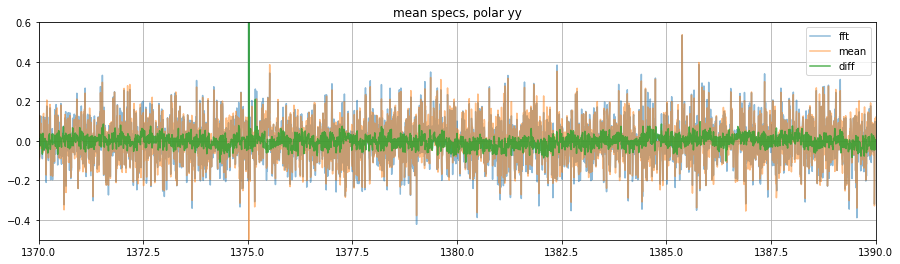

In [101]:
fig = plt.figure(figsize=(15,4))
ax = fig.add_subplot(111)
t1,t2 = tn-5,tn+5
diff = np.mean(rmsw_data[t1:t2],axis=0) - np.mean(rmsw_data_mean[t1:t2],axis=0)
med = np.median(diff)
ax.plot(freq,np.mean(rmsw_data[t1:t2],axis=0),label='fft',alpha = .5)
ax.plot(freq,np.mean(rmsw_data_mean[t1:t2],axis=0)+med,label='mean',alpha = .5)
ax.plot(freq,diff-med,alpha = .8,label='diff')
ax.set_xlim(1370,1390)
ax.set_ylim(-.5,.6) 
ax.grid();ax.legend();ax.set_title(f'mean specs, polar yy')

RFI会有变化，所以会减出负值。平均太多驻波相位会有变化。noise on与off变化明显，所以不应平均太多。太少会失去源的流量。需要注意，由于不同谱线基线不同，还需要使用cli_baseline.py多项式去一次基线。